# Comprehensive Exploratory Data Analysis (EDA)
**Dataset:** Customer Support Tickets

This notebook explores customer support ticket data to uncover patterns in ticket volume, resolution times, agent performance, and customer satisfaction.

## Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Load the dataset
df = pd.read_csv('Data/customer_support_tickets.csv')


## Basic Data Overview

In [2]:
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

print("--- Data Types & Missing Values ---")
df.info()

print("\n--- Summary Statistics (Numerical) ---")
display(df.describe())

print("\n--- Summary Statistics (Categorical) ---")
display(df.describe(include=['object']))

Dataset Shape: 20000 rows, 12 columns

--- Data Types & Missing Values ---
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Ticket_ID              20000 non-null  str  
 1   Customer_Name          20000 non-null  str  
 2   Customer_Email         20000 non-null  str  
 3   Ticket_Subject         20000 non-null  str  
 4   Ticket_Description     20000 non-null  str  
 5   Issue_Category         20000 non-null  str  
 6   Priority_Level         20000 non-null  str  
 7   Ticket_Channel         20000 non-null  str  
 8   Submission_Date        20000 non-null  str  
 9   Resolution_Time_Hours  20000 non-null  int64
 10  Assigned_Agent         20000 non-null  str  
 11  Satisfaction_Score     20000 non-null  int64
dtypes: int64(2), str(10)
memory usage: 1.8 MB

--- Summary Statistics (Numerical) ---


,Resolution_Time_Hours,Satisfaction_Score
count,20000.000000,20000.000000
mean,39.230300,3.723700
std,35.221884,1.286989
min,1.000000,1.000000
25%,11.000000,3.000000
50%,27.000000,4.000000
75%,58.000000,5.000000
max,120.000000,5.000000



--- Summary Statistics (Categorical) ---


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_24820\4185709892.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=['object']))


,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Assigned_Agent
count,20000,20000,20000,20000,20000,20000,20000,20000,20000,20000
unique,20000,17900,19489,13943,20000,5,4,3,731,5
top,TKT-100000,William Smith,njohnson@example.com,App crashing - During,"Hi Support, Where is your headquarters located...",Technical,Low,Chat,2025-05-11,Anya Sharma
freq,1,11,4,5,1,5918,7716,6693,45,4025


In [3]:
# Convert Submission_Date to datetime objects
df['Submission_Date'] = pd.to_datetime(df['Submission_Date'])

# Display the first few rows
display(df.head())

,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,Anya Sharma,5
3,TKT-100003,Rachel Bullock,katherine67@example.net,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,2025-03-20,41,Anya Sharma,5
4,TKT-100004,Thomas Parks DDS,raykelsey@example.com,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,2025-04-27,40,David Kim,5


In [5]:
nulls = df.isnull().sum()
nulls_percent = (nulls / len(df)) * 100
nulls_df = pd.DataFrame({'Null Count': nulls, 'Null Percentage': nulls_percent}).T
print(nulls_df)

                 Ticket_ID  Customer_Name  Customer_Email  Ticket_Subject  \
Null Count             0.0            0.0             0.0             0.0   
Null Percentage        0.0            0.0             0.0             0.0   

                 Ticket_Description  Issue_Category  Priority_Level  \
Null Count                      0.0             0.0             0.0   
Null Percentage                 0.0             0.0             0.0   

                 Ticket_Channel  Submission_Date  Resolution_Time_Hours  \
Null Count                  0.0              0.0                    0.0   
Null Percentage             0.0              0.0                    0.0   

                 Assigned_Agent  Satisfaction_Score  
Null Count                  0.0                 0.0  
Null Percentage             0.0                 0.0  


In [7]:
df.drop_duplicates(inplace=True)

In [8]:
# Set styling for plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)


## Univariate Analysis

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_24820\2319807728.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Satisfaction_Score', ax=axes[1, 1], palette='viridis')


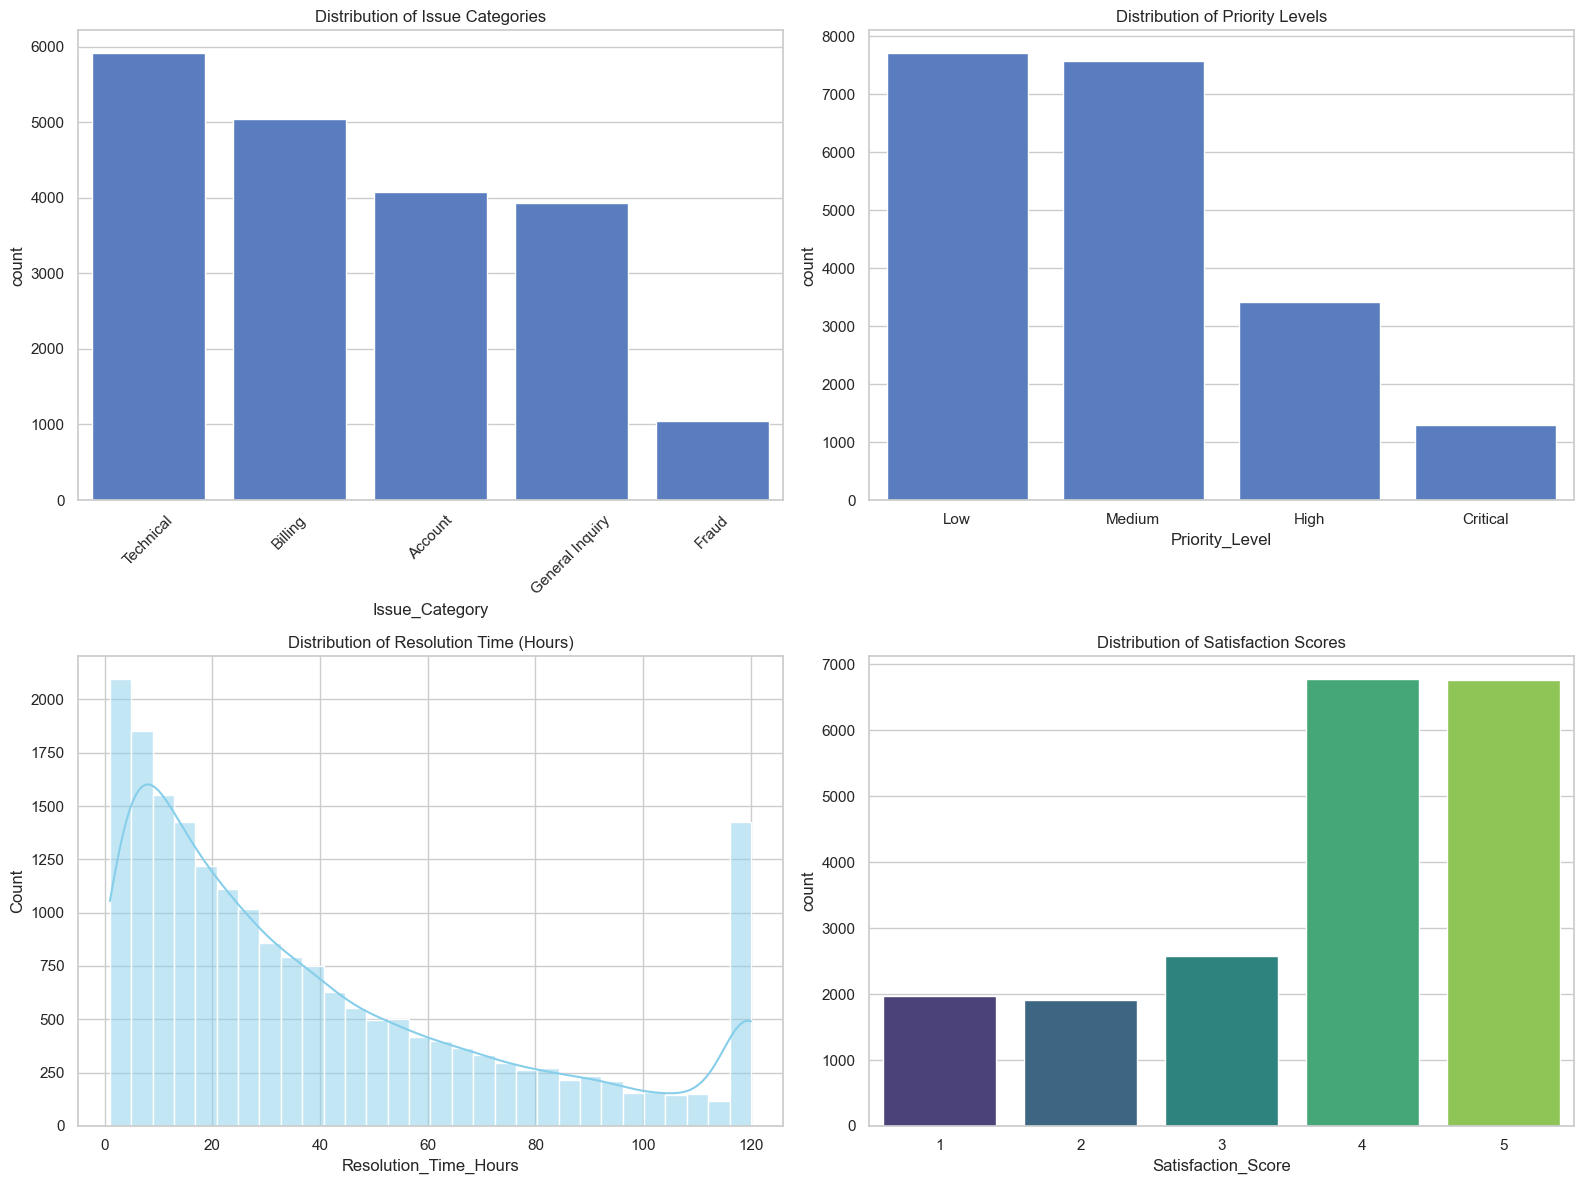

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Issue Category Distribution
sns.countplot(data=df, x='Issue_Category', ax=axes[0, 0], order=df['Issue_Category'].value_counts().index)
axes[0, 0].set_title('Distribution of Issue Categories')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Priority Level Distribution
priority_order = ['Low', 'Medium', 'High', 'Critical']
sns.countplot(data=df, x='Priority_Level', ax=axes[0, 1], order=priority_order)
axes[0, 1].set_title('Distribution of Priority Levels')

# 3. Resolution Time Distribution
sns.histplot(data=df, x='Resolution_Time_Hours', bins=30, kde=True, ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Distribution of Resolution Time (Hours)')

# 4. Satisfaction Score Distribution
sns.countplot(data=df, x='Satisfaction_Score', ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Distribution of Satisfaction Scores')

plt.tight_layout()
plt.show()

## Time Series Analysis


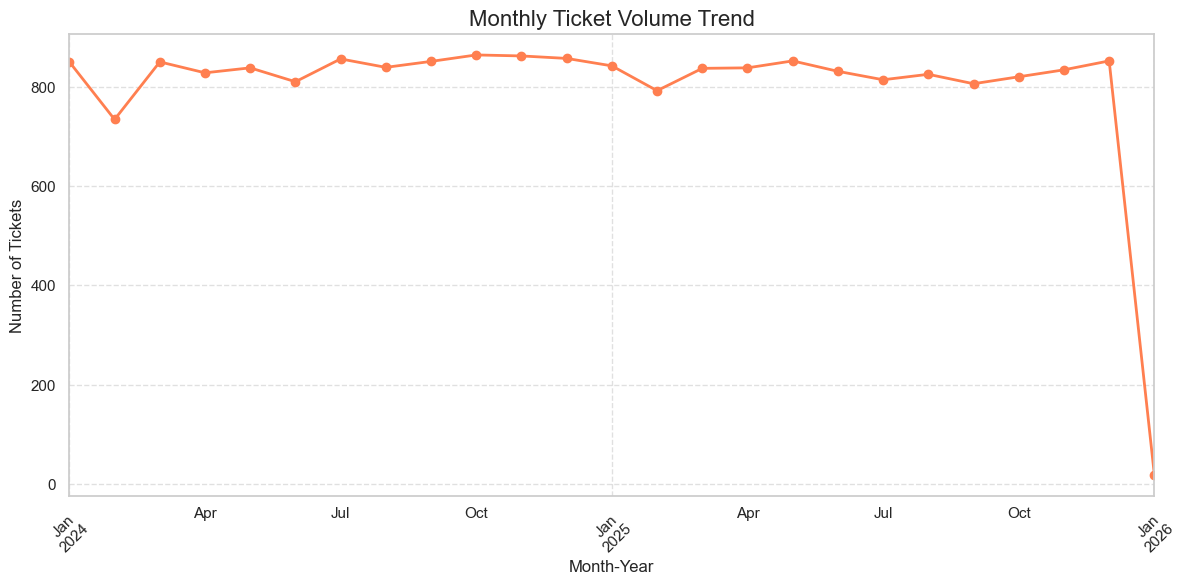

In [10]:
# Create a Year-Month column for aggregation
df['YearMonth'] = df['Submission_Date'].dt.to_period('M')

# Group by YearMonth
monthly_tickets = df.groupby('YearMonth').size()

plt.figure(figsize=(14, 6))
monthly_tickets.plot(kind='line', marker='o', color='coral', linewidth=2)
plt.title('Monthly Ticket Volume Trend', fontsize=16)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Number of Tickets', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Bivariate & Multivariate Analysis


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_24820\2294331880.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Priority_Level', y='Resolution_Time_Hours', order=priority_order, ax=axes[0], palette='Set2')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_24820\2294331880.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Issue_Category', y='Satisfaction_Score', ax=axes[1], palette='Set3', errorbar=None)


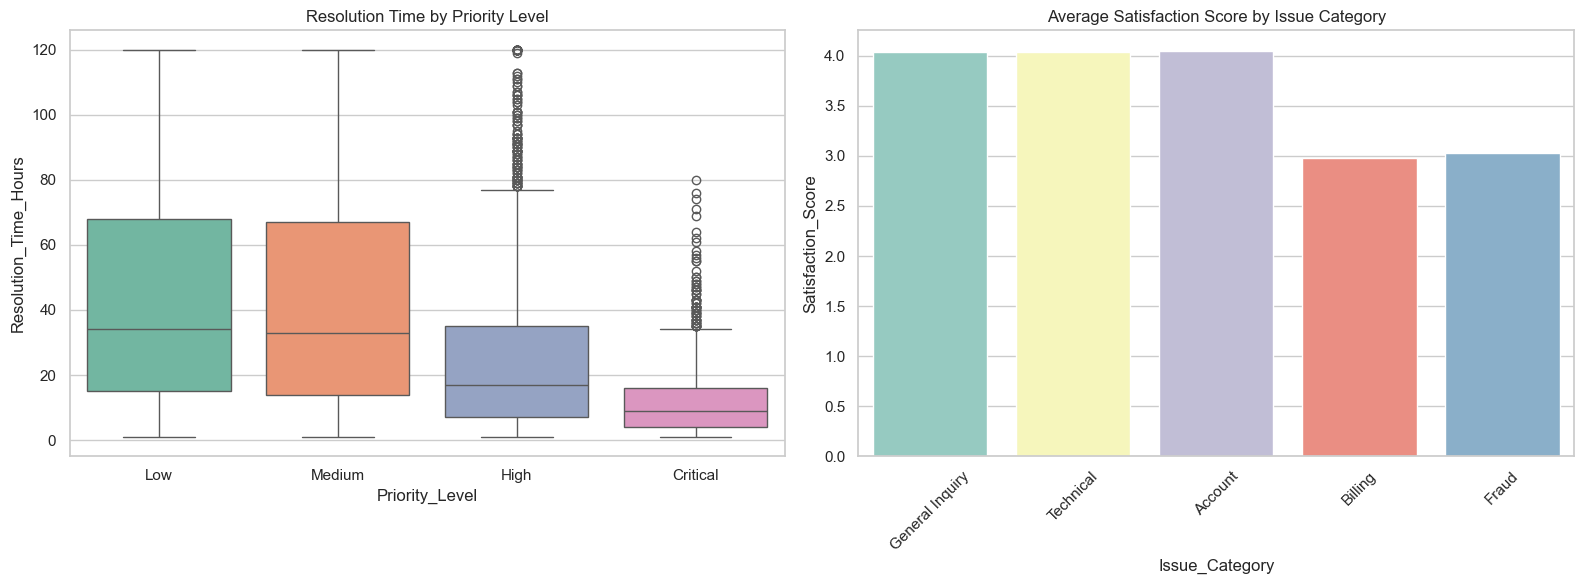

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Resolution Time vs Priority Level
sns.boxplot(data=df, x='Priority_Level', y='Resolution_Time_Hours', order=priority_order, ax=axes[0], palette='Set2')
axes[0].set_title('Resolution Time by Priority Level')

# Satisfaction Score vs Issue Category
sns.barplot(data=df, x='Issue_Category', y='Satisfaction_Score', ax=axes[1], palette='Set3', errorbar=None)
axes[1].set_title('Average Satisfaction Score by Issue Category')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Agent Performance Analysis

,Assigned_Agent,Tickets_Handled,Avg_Resolution_Time,Avg_Satisfaction
0,Anya Sharma,4025,40.435776,3.714534
1,Ben Carter,4010,37.400499,3.727431
2,Chloe Adams,4006,39.619321,3.737644
3,David Kim,3989,39.169717,3.718225
4,Elena Rodriguez,3970,39.524685,3.720655


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_24820\1111756941.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agent_stats.head(10), x='Assigned_Agent', y='Tickets_Handled', palette='coolwarm')


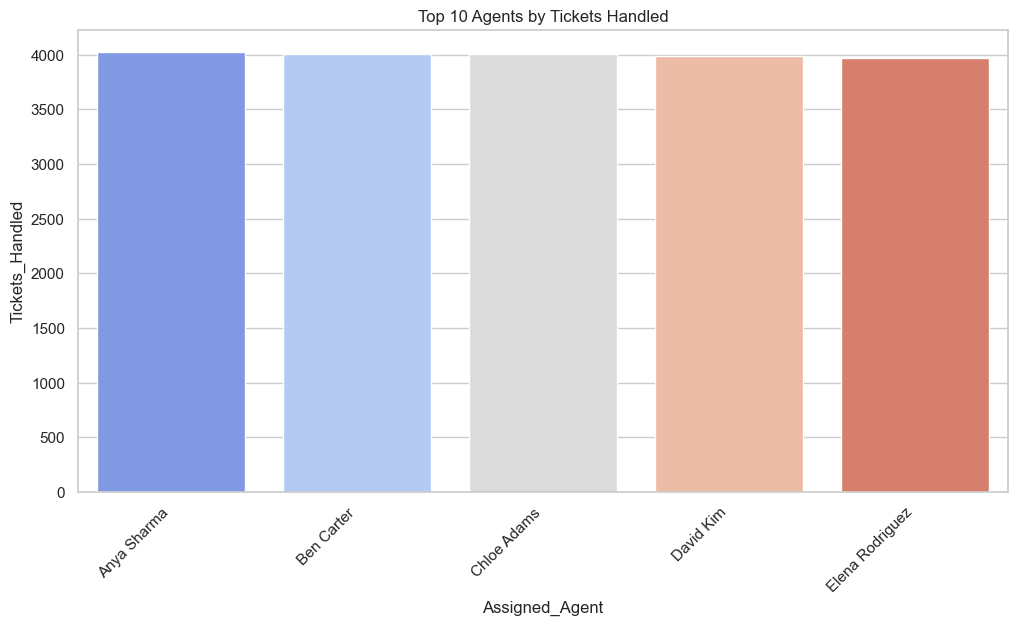

In [12]:
# Aggregate metrics by Agent
agent_stats = df.groupby('Assigned_Agent').agg(
    Tickets_Handled=('Ticket_ID', 'count'),
    Avg_Resolution_Time=('Resolution_Time_Hours', 'mean'),
    Avg_Satisfaction=('Satisfaction_Score', 'mean')
).reset_index().sort_values(by='Tickets_Handled', ascending=False)

display(agent_stats.head(10))

# Visualizing Top 10 Agents by Ticket Volume
plt.figure(figsize=(12, 6))
sns.barplot(data=agent_stats.head(10), x='Assigned_Agent', y='Tickets_Handled', palette='coolwarm')
plt.title('Top 10 Agents by Tickets Handled')
plt.xticks(rotation=45, ha='right')
plt.show()

## Basic Text Analysis


--- Description Character Length Summary ---


,count,mean,std,min,25%,50%,75%,max
description_length,20000.0,99.6187,14.74394,60.0,89.0,99.0,110.0,153.0



--- Description Word Count Summary ---


,count,mean,std,min,25%,50%,75%,max
description_word_count,20000.0,16.931,2.391114,10.0,15.0,17.0,19.0,23.0


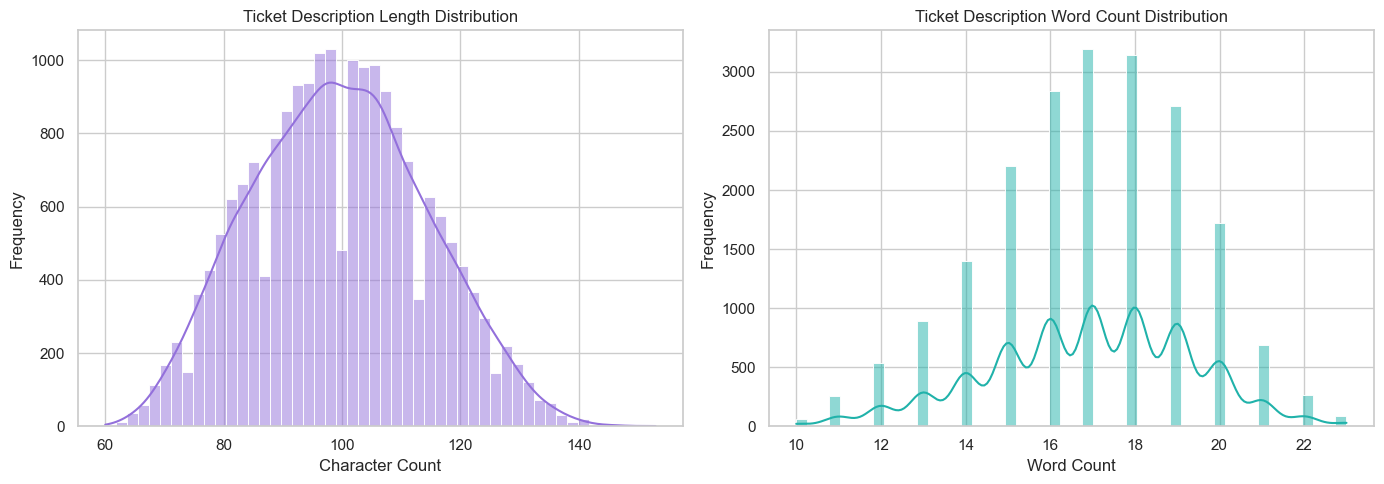

In [15]:
# Create new columns for character length and word count
df['description_length'] = df['Ticket_Description'].str.len()
df['description_word_count'] = df['Ticket_Description'].str.split().str.len()

# Display summary statistics
print("--- Description Character Length Summary ---")
display(df['description_length'].describe().to_frame().T)

print("\n--- Description Word Count Summary ---")
display(df['description_word_count'].describe().to_frame().T)

# Visualize the distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Character Count Distribution
sns.histplot(df['description_length'], bins=50, kde=True, ax=axes[0], color='mediumpurple')
axes[0].set_title('Ticket Description Length Distribution')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')

# Plot 2: Word Count Distribution
sns.histplot(df['description_word_count'], bins=50, kde=True, ax=axes[1], color='lightseagreen')
axes[1].set_title('Ticket Description Word Count Distribution')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

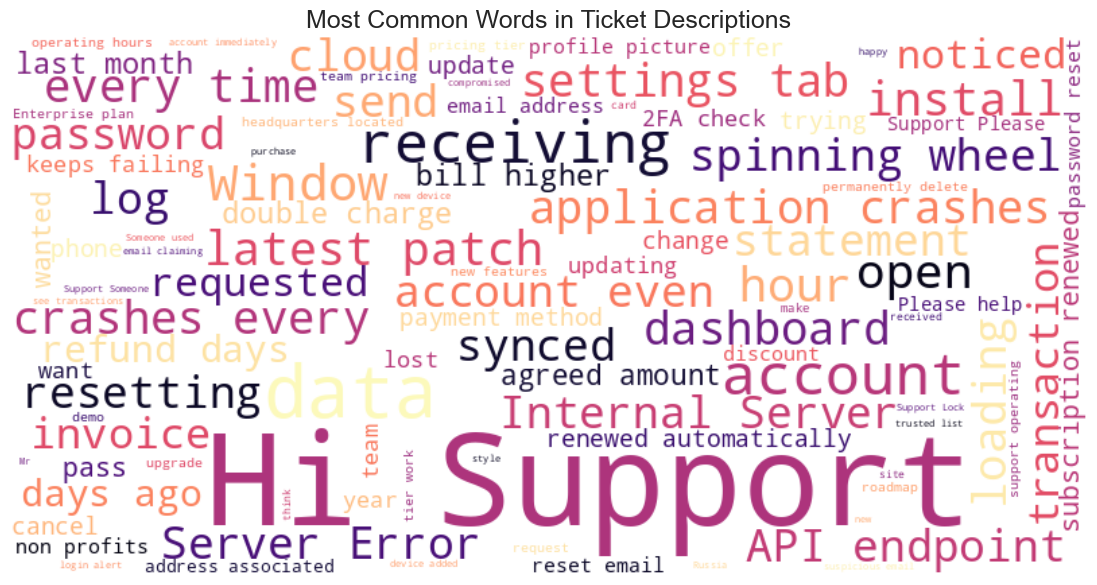

In [16]:
# Combine all ticket descriptions into a single massive string
text_data = " ".join(desc for desc in df['Ticket_Description'].dropna())

# Generate the word cloud
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    colormap='magma', 
    max_words=100
).generate(text_data)

# Display the word cloud
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Ticket Descriptions', fontsize=18)
plt.show()

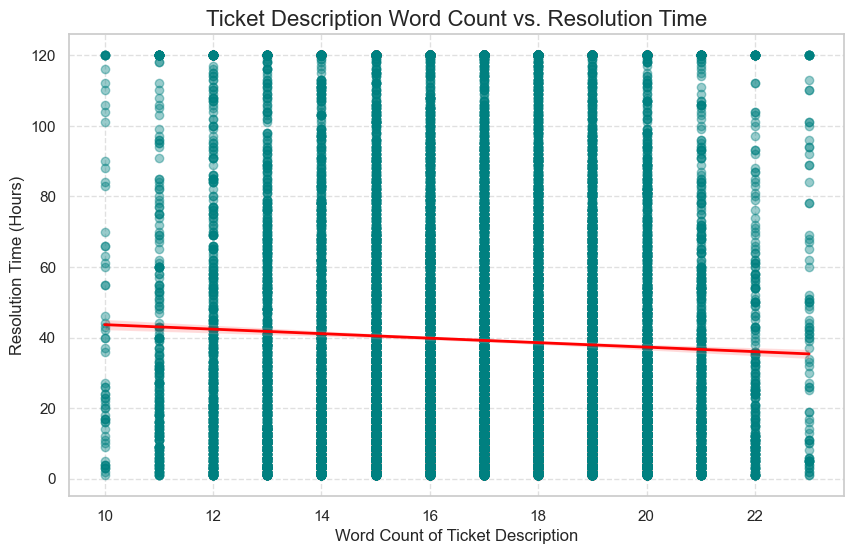

Correlation Coefficient: -0.0433


In [17]:
plt.figure(figsize=(10, 6))

# Create a scatter plot with a regression line (trendline)
sns.regplot(
    data=df, 
    x='description_word_count', 
    y='Resolution_Time_Hours', 
    scatter_kws={'alpha': 0.4, 'color': 'teal'}, # Alpha makes overlapping points readable
    line_kws={'color': 'red', 'linewidth': 2}    # Red trendline
)

plt.title('Ticket Description Word Count vs. Resolution Time', fontsize=16)
plt.xlabel('Word Count of Ticket Description', fontsize=12)
plt.ylabel('Resolution Time (Hours)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

# Calculate and print the correlation coefficient
correlation = df['description_word_count'].corr(df['Resolution_Time_Hours'])
print(f"Correlation Coefficient: {correlation:.4f}")

## Operational Insights: Day of the Week Analysis

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_24820\3775995119.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


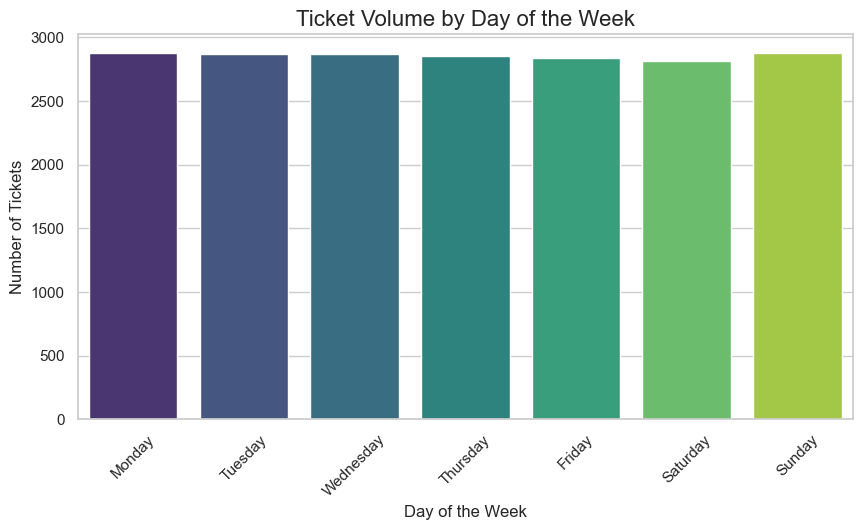

In [18]:
# Extract the day of the week
df['DayOfWeek'] = df['Submission_Date'].dt.day_name()

# Order the days correctly
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df, 
    x='DayOfWeek', 
    order=days_order, 
    palette='viridis'
)
plt.title('Ticket Volume by Day of the Week', fontsize=16)
plt.xlabel('Day of the Week')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45)
plt.show()

## Business Metrics: Service Level Agreements Breach Analysis

Overall SLA Breach Rate (>24 hours): 53.73%



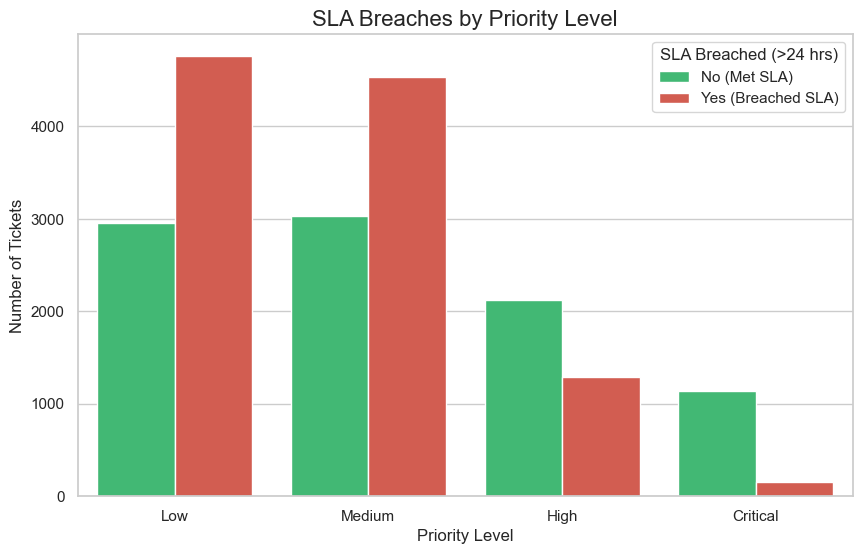

In [19]:
# Define SLA threshold (e.g., 24 hours)
SLA_THRESHOLD = 24

# Create a new column indicating if the SLA was breached
df['SLA_Breached'] = df['Resolution_Time_Hours'] > SLA_THRESHOLD

# Calculate overall breach rate
breach_rate = df['SLA_Breached'].mean() * 100
print(f"Overall SLA Breach Rate (>24 hours): {breach_rate:.2f}%\n")

# Visualizing SLA Breaches by Priority Level
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df, 
    x='Priority_Level', 
    hue='SLA_Breached', 
    order=['Low', 'Medium', 'High', 'Critical'], 
    palette=['#2ecc71', '#e74c3c'] # Green for False (Met), Red for True (Breached)
)
plt.title('SLA Breaches by Priority Level', fontsize=16)
plt.xlabel('Priority Level')
plt.ylabel('Number of Tickets')
plt.legend(title='SLA Breached (>24 hrs)', labels=['No (Met SLA)', 'Yes (Breached SLA)'])
plt.show()

## Statistical Summary: Correlation Heatmap


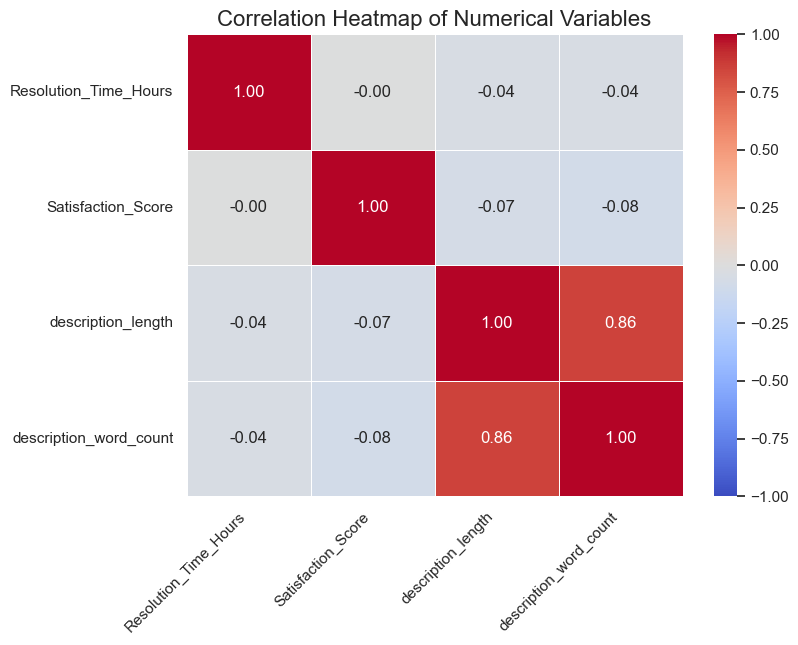

In [20]:
# Select only numerical columns for correlation
numerical_cols = [
    'Resolution_Time_Hours', 
    'Satisfaction_Score', 
    'description_length', 
    'description_word_count'
]

# Calculate the correlation matrix
corr_matrix = df[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Show the numbers inside the squares
    cmap='coolwarm',     # Blue for negative, Red for positive correlation
    fmt='.2f',           # Round to 2 decimal places
    linewidths=0.5,
    vmin=-1, vmax=1      # Set scale from -1 to 1
)
plt.title('Correlation Heatmap of Numerical Variables', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show()